# RAVDESS — EDA, Cleaning & Preprocessing

**Dataset**: Ryerson Audio-Visual Database of Emotional Speech and Song
**Role in EmoCare**: Primary speech emotion dataset

## 0. Imports & Paths

In [1]:
import os, sys, glob, re, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, librosa.display

PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR       = os.path.join(PROJECT_ROOT, 'data', 'raw', 'ravdess')
INTERIM_DIR   = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

EMOTION_MAP   = {'01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fearful','07':'disgust','08':'surprised'}
INTENSITY_MAP = {'01':'normal','02':'strong'}
MODALITY_MAP  = {'01':'audio-video','02':'video','03':'audio-only'}
print('Project root:', PROJECT_ROOT)

Project root: D:\EmoCare


## 1. Build Metadata from Filenames

In [2]:
def parse_ravdess_filename(filepath: str) -> dict:
    fname = os.path.basename(filepath).replace('.wav', '')
    parts = fname.split('-')
    if len(parts) != 7: return None
    return {
        'filepath': filepath, 'filename': os.path.basename(filepath),
        'modality': MODALITY_MAP.get(parts[0], parts[0]),
        'channel': parts[1], 'emotion_id': parts[2],
        'emotion': EMOTION_MAP.get(parts[2], 'unknown'),
        'intensity': INTENSITY_MAP.get(parts[3], parts[3]),
        'statement': parts[4], 'repetition': parts[5],
        'actor_id': int(parts[6]),
        'gender': 'female' if int(parts[6]) % 2 == 0 else 'male'
    }

all_files = glob.glob(os.path.join(RAW_DIR, 'Actor_*', '*.wav'))
records = [parse_ravdess_filename(f) for f in all_files if parse_ravdess_filename(f) is not None]
df = pd.DataFrame(records)
print('Parsed RAVDESS records:', len(df))
df.head()

Parsed RAVDESS records: 1440


,filepath,filename,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor_id,gender
0,D:\EmoCare\data\raw\ravdess\Actor_01\03-01-01-...,03-01-01-01-01-01-01.wav,audio-only,01,01,neutral,normal,01,01,1,male
1,D:\EmoCare\data\raw\ravdess\Actor_01\03-01-01-...,03-01-01-01-01-02-01.wav,audio-only,01,01,neutral,normal,01,02,1,male
2,D:\EmoCare\data\raw\ravdess\Actor_01\03-01-01-...,03-01-01-01-02-01-01.wav,audio-only,01,01,neutral,normal,02,01,1,male
3,D:\EmoCare\data\raw\ravdess\Actor_01\03-01-01-...,03-01-01-01-02-02-01.wav,audio-only,01,01,neutral,normal,02,02,1,male
4,D:\EmoCare\data\raw\ravdess\Actor_01\03-01-02-...,03-01-02-01-01-01-01.wav,audio-only,01,02,calm,normal,01,01,1,male


## 2. EDA — Class Distribution & Demographics

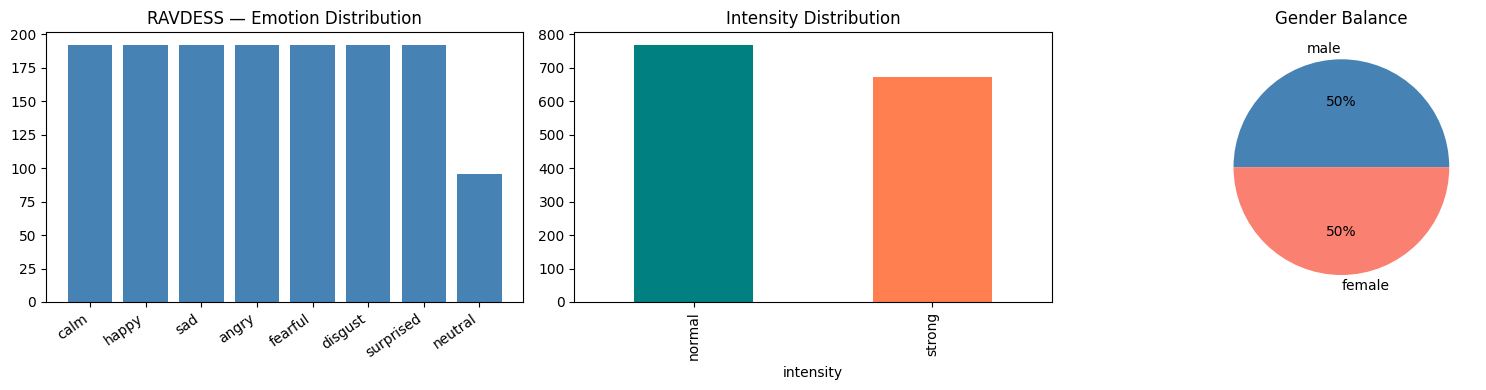

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
emotion_counts = df['emotion'].value_counts()
axes[0].bar(emotion_counts.index, emotion_counts.values, color='steelblue')
axes[0].set_title('RAVDESS — Emotion Distribution')
axes[0].set_xticklabels(emotion_counts.index, rotation=35, ha='right')
df['intensity'].value_counts().plot(kind='bar', ax=axes[1], color=['teal', 'coral'])
axes[1].set_title('Intensity Distribution')
df['gender'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.0f%%', colors=['steelblue', 'salmon'])
axes[2].set_title('Gender Balance')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'ravdess_distributions.png'), dpi=150)
plt.show()

## 3. Audio QA — Waveforms & Spectrograms

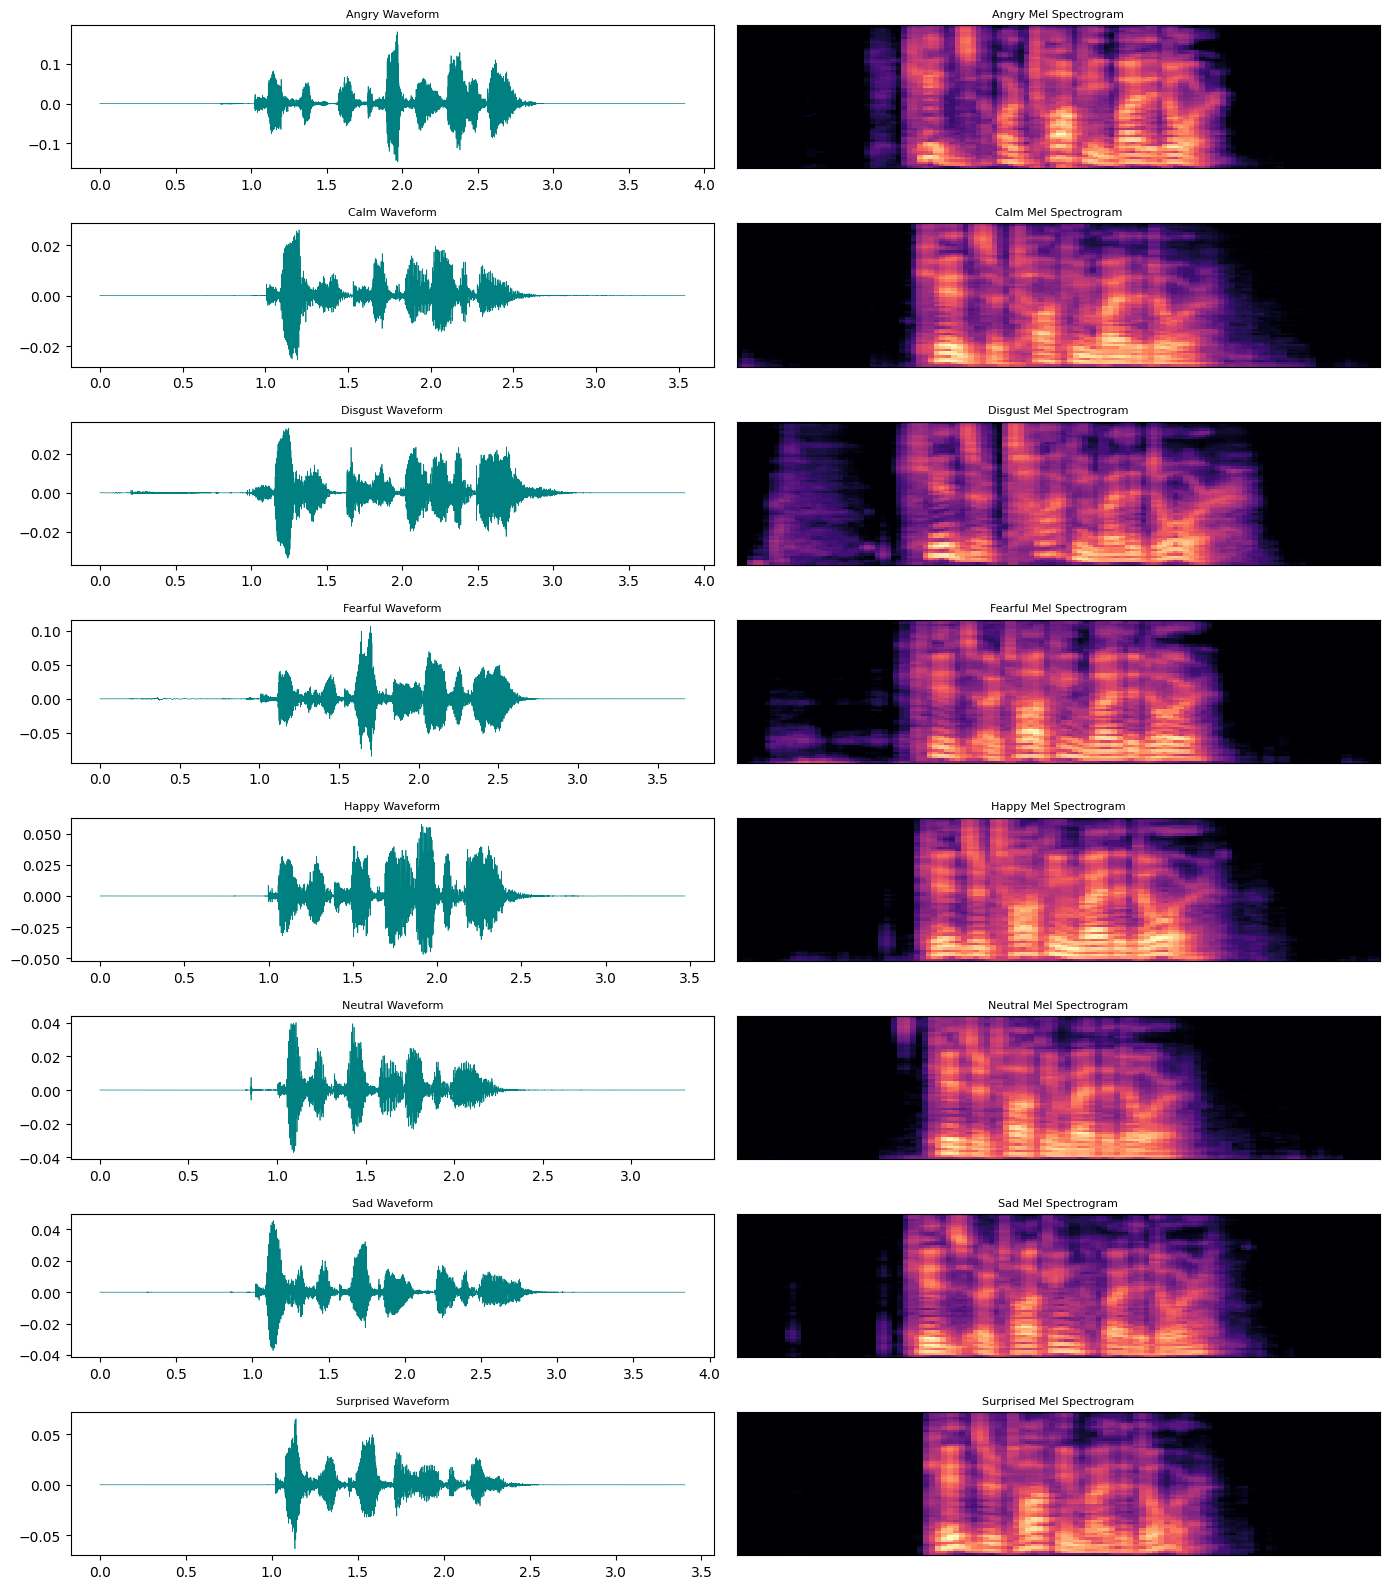

In [4]:
sample_files = df.groupby('emotion').first()['filepath'].to_dict()
fig, axes = plt.subplots(len(sample_files), 2, figsize=(14, len(sample_files)*2))
for idx, (emo, fp) in enumerate(sample_files.items()):
    y, sr = librosa.load(fp, sr=16000)
    axes[idx][0].plot(np.linspace(0, len(y)/sr, len(y)), y, color='teal', linewidth=0.5)
    axes[idx][0].set_title(f'{emo.capitalize()} Waveform', fontsize=8)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), sr=sr, ax=axes[idx][1], cmap='magma')
    axes[idx][1].set_title(f'{emo.capitalize()} Mel Spectrogram', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'ravdess_waveforms.png'), dpi=120)
plt.show()

## 4. Acoustic Features & Splits

In [5]:
feat_path = os.path.join(PROCESSED_DIR, 'ravdess_features.csv')
df_features = pd.read_csv(feat_path)
print('Loaded pre-extracted features:', len(df_features), 'records | Shape:', df_features.shape)
df_features.head()

Loaded pre-extracted features: 1440 records | Shape: (1440, 103)


,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,duration_s,pause_ratio,filename,emotion,emotion_id,intensity,actor_id,gender,modality,split
0,-678.079041,201.207001,51.527710,63.235027,-0.038087,24.725830,14.368165,18.862400,0.833891,18.244806,...,3.269938,0.656607,03-01-01-01-02-01-01.wav,neutral,1,normal,1,male,audio-only,train
1,-674.439636,195.710541,50.828197,59.287537,1.724960,23.106594,14.461128,20.831026,3.074211,15.942347,...,3.169875,0.664419,03-01-01-01-02-02-01.wav,neutral,1,normal,1,male,audio-only,train
2,-694.231506,202.899399,50.040554,65.421242,0.552266,23.770517,14.545629,24.151520,3.444762,15.810365,...,3.303313,0.658487,03-01-01-01-01-01-01.wav,neutral,1,normal,1,male,audio-only,train
3,-683.919617,199.061646,49.147438,60.508026,-1.772322,19.593533,19.475555,22.297804,1.976955,16.608458,...,3.336688,0.659599,03-01-01-01-01-02-01.wav,neutral,1,normal,1,male,audio-only,train
4,-695.869751,182.287979,61.871300,67.213676,-0.804282,24.526930,14.567588,21.163734,4.735579,17.199860,...,3.603625,0.593049,03-01-02-01-01-02-01.wav,calm,2,normal,1,male,audio-only,train


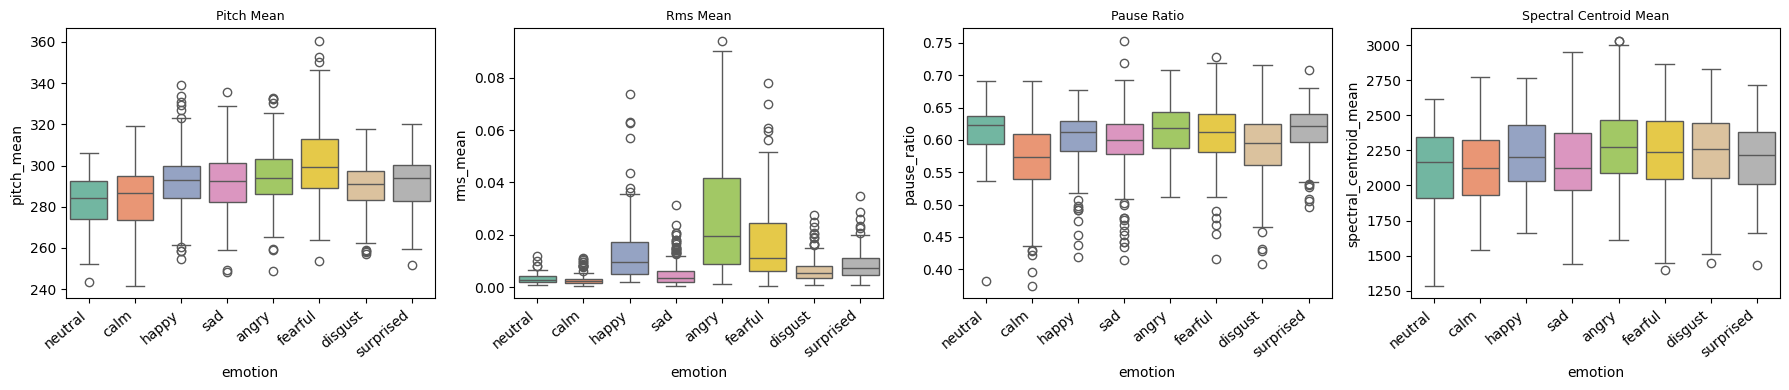

In [6]:
key_feats = ['pitch_mean', 'rms_mean', 'pause_ratio', 'spectral_centroid_mean']
fig, axes = plt.subplots(1, len(key_feats), figsize=(18, 4))
for ax, feat in zip(axes, key_feats):
    sns.boxplot(data=df_features, x='emotion', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'ravdess_feature_boxplots.png'), dpi=150)
plt.show()

## 5. Verification & Split Summary

In [7]:
print('=== RAVDESS Split Counts ===')
print(df_features['split'].value_counts())
print('=== Emotion per Split ===')
print(df_features.groupby(['split', 'emotion']).size().unstack(fill_value=0))

=== RAVDESS Split Counts ===
split
train    1020
val       240
test      180
Name: count, dtype: int64
=== Emotion per Split ===
emotion  angry  calm  disgust  fearful  happy  neutral  sad  surprised
split                                                                 
test        24    24       24       24     24       12   24         24
train      136   136      136      136    136       68  136        136
val         32    32       32       32     32       16   32         32
